# Predictor de diabetes
## Modelo de machine learning para predecir la probabilidad de desarrollar diabetes

Este proyecto entrena y selecciona el mejor modelo de machine learning para predecir la probabilidad de desarrollar diabetes con base en datos demográficos y clínicos.

El dataset para este proyecto es obtenido de Kaggle, disponible en el siguiente enlace:https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

### EDA

In [1]:
# Importar librerías necesarias
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import os

import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\lbtoj\OneDrive\Escritorio\Data Science\Prácticas adicionales\Diabetes-prediction\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Descargar la versión más reciente del dataset de Kaggle
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

print("Path to dataset files:", path)

# Mostrar los archivos descargados
os.listdir(path)

Path to dataset files: C:\Users\lbtoj\.cache\kagglehub\datasets\iammustafatz\diabetes-prediction-dataset\versions\1


['diabetes_prediction_dataset.csv']

In [3]:
# Ruta al archivo CSV descargado de Kaggle
csv_path = os.path.join(path, 'diabetes_prediction_dataset.csv')

# Cargar el dataset en un DataFrame de pandas
df = pd.read_csv(csv_path)

# Mostrar las primeras filas del DataFrame
display(df.head())

# Mostrar la informacióñn general del DataFrame
df.info()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), str(2)
memory usage: 6.9 MB


In [4]:
# Mostrar estadísticas descriptivas del DataFrame
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [ ]:
# Exploración de valores unicos en columnas categoricas y binarias
binary_columns = ['hypertension', 'heart_disease']
categorical_columns = ['gender', 'smoking_history']

for col in binary_columns:
    print(f"Valores únicos en la columna '{col}': {df[col].unique()}")
    
for col in categorical_columns:
    print()
    print(f"Valores únicos en la columna '{col}': {df[col].unique()}")


Valores únicos en la columna 'hypertension': [0 1]
Valores únicos en la columna 'heart_disease': [1 0]

Valores únicos en la columna 'gender': <StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: str

Valores únicos en la columna 'smoking_history': <StringArray>
['never', 'No Info', 'current', 'former', 'ever', 'not current']
Length: 6, dtype: str


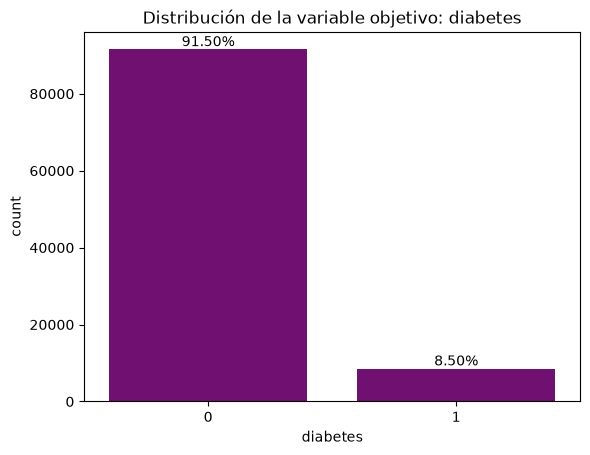

In [21]:
# Exploración de la distribución de la variable objetivo 'diabetes'
ax = sns.countplot(x='diabetes', data=df, color='purple')
plt.title('Distribución de la variable objetivo: diabetes')

# Mostrar el porcentaje de cada clase en el gráfico
total = len(df)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total

    ax.annotate(
        f'{percentage:.2f}%',
        (p.get_x() + p.get_width() / 2, count),
        ha='center',
        va='bottom'
    )

plt.show()

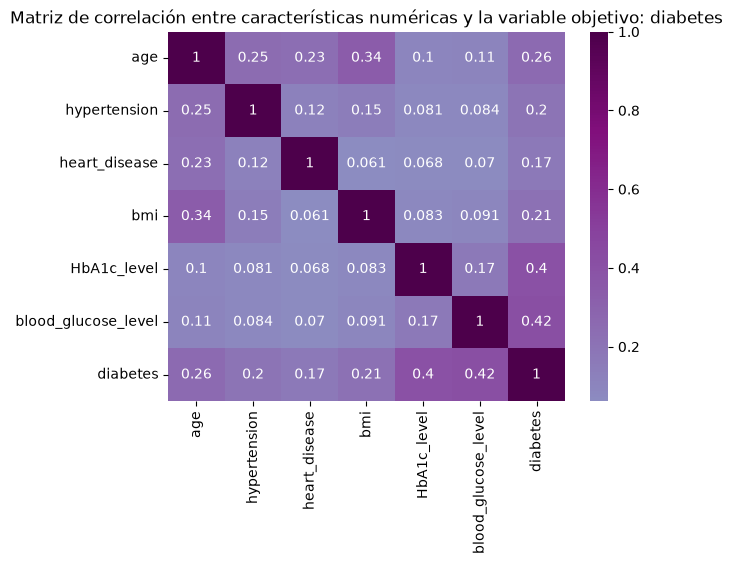

In [6]:
# Correlación entre las características numéricas y la variable objetivo 'diabetes'
# Columnas numéricas
numeric_columns = df.select_dtypes(include=['float64', 'int64']).columns

# Mapa de calor de correlación
correlation_matrix = df[numeric_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='BuPu', center=0)
plt.title('Matriz de correlación entre características numéricas y la variable objetivo: diabetes')
plt.show()

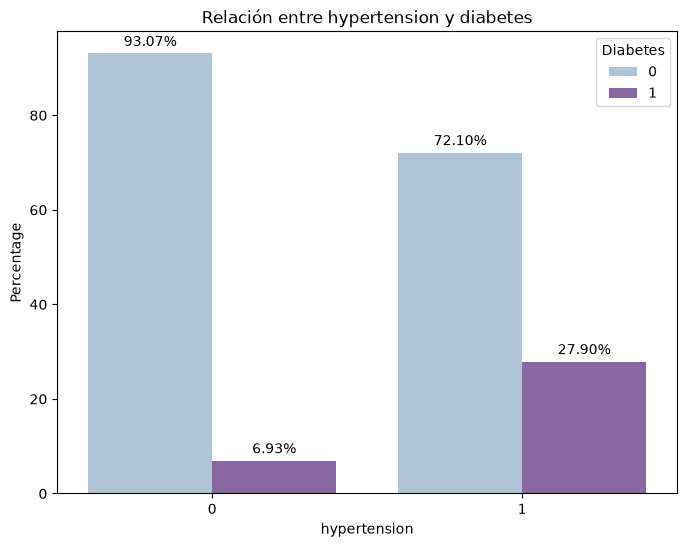

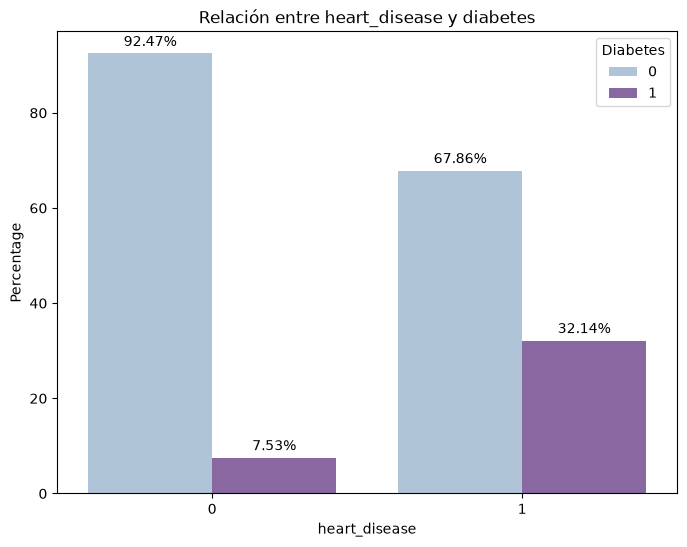

In [ ]:
# Relación entre variables binarias y la variable objetivo
for column in binary_columns:

    proportions = (
        df.groupby(column)['diabetes']
        .value_counts(normalize=True)
        .mul(100)
        .rename('percentage')
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=proportions,
        x=column,
        y='percentage',
        hue='diabetes',
        palette='BuPu'
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f%%',
            padding=3
        )

    plt.title(
        f'Relación entre {column} y diabetes'
    )

    plt.xlabel(column)
    plt.ylabel('Percentage')
    plt.legend(title='Diabetes')
    plt.show()


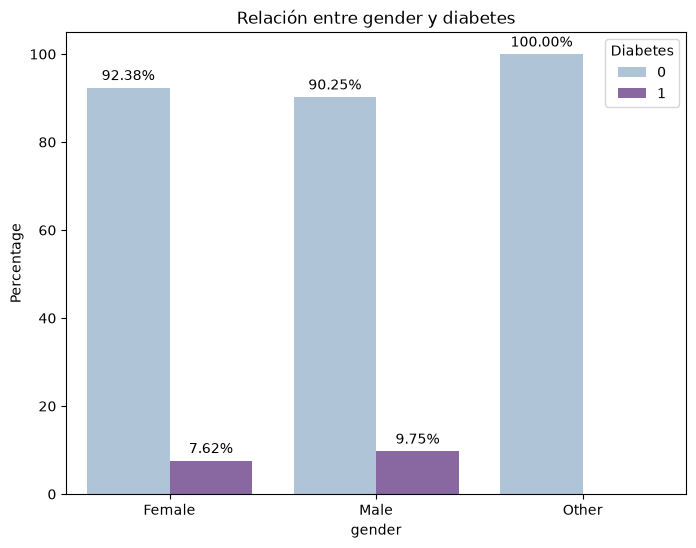

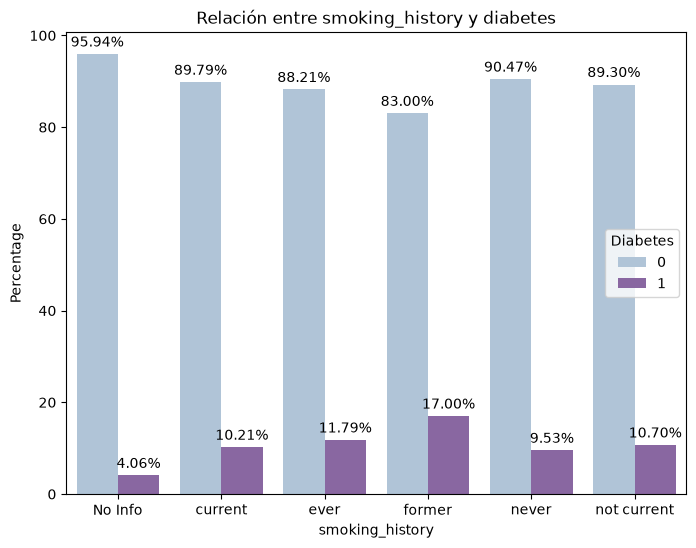

In [ ]:
# Relación entre variables categóricas y la variable objetivo
for column in categorical_columns:

    proportions = (
        df.groupby(column)['diabetes']
        .value_counts(normalize=True)
        .mul(100)
        .rename('percentage')
        .reset_index()
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=proportions,
        x=column,
        y='percentage',
        hue='diabetes',
        palette='BuPu'
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.2f%%',
            padding=3
        )

    plt.title(
        f'Relación entre {column} y diabetes'
    )

    plt.xlabel(column)
    plt.ylabel('Percentage')
    plt.legend(title='Diabetes')
    plt.show()

#### Conclusiones de EDA
- El DataFrame cargado contiene 100,000 registros sin valores nulos 
- La mediana de edad es de 43 años
- La mediana de Indice de Masa Corporal (BMI) 27 lo cual indica sobrepeso 
- La mediana de hemoglobina glucosilada (HbA1c) es de 5.8
- La mediana de niveles de glucosa es de 140
- Hay un claro desbalance de clases en la variable objetivo: 
    - 91.5% no tiene diabetes
    - 8.5% tiene diabetes
- Solo HbA1c y los niveles de glucosa en sangre tienen una correlación de Pearson moderadamente fuerte con la variable objetivo
- Hay 302% mayor riesgo relativo de diabetes en personas con hipertensión que sin hipertensión (27.9% vs 6.93%)
- Hay 326% mayor riesgo relativo de diabetes en personas con enfermedad cardiaca que sin ella (32.14% vs 7.53) 
- Hay 27% más de riesgo relativo de diabetes en hombres que en mujeres (9.75% vs 7.62%)
- La población que refiere haber fumado, pero dejado de hacerlo, es la que tiene la mayor proporción de diabetes (17%)
- Llama la atención que la proporción de personas con diabetes (9.53%) que refiere nunca haber fumado es similar a los que actualmente fuman (10.21%) o que fumaron alguna vez (11.79%)
    - ¿Qué características comparten estas poblaciones?
